# Lung segmentation from thoracic X-Ray images with UNET

*by Georgios K. Ouzounis*

## Contents

1. [The challenge](#the-challenge)
2. [Get the training data](#get-the-training-data)
3. [Get the code repo](#get-the-code-repo)
4. [Create the model](#create-the-model)
5. [Train the model](#train-the-model)
6. [Inference on test images](#inference-on-test-images)
7. [Acknowledgements](#acknowledgements)

## The challenge <a name="the-challenge"></a>

<img src="https://raw.githubusercontent.com/georgiosouzounis/lung-seg-xray-unet/main/images/title2.png" width = "600"/>

Given an annotated image dataset of lungs from thoracic x-ray images, train a semantic segmentation model (UNET) and compute inference on new, previously unseen images.

**DISCLAIMER:**
In the following, "author" refers to Georgios Ouzounis.

- The work presented in this notebook is independent from past works of the author at varius companies and institutions. It is different with regards to the technology and code used and does not relate to any prior products, research work or IP developed by the author.
- This notebook (code) is developed explicitly for educational purposes, demonstrating how one can train the UNET model. It is not meant for any other usage and the author cannot be held accountable for its outcome and deliverables if used for a purpose different from the one stated.   

**IMPORTANT:** before start working on this notebook change your Runtime setting to GPU.

## Get the training data <a name="get-the-training-data"></a>

For this exercise will use a publicly available dataset of thoracic X-Ray images. It is posted in [kaggle.com](https://www.kaggle.com/nikhilpandey360/chest-xray-masks-and-labels) and is a kind contribution by [Nikhil Pandey](https://www.kaggle.com/nikhilpandey360). The archived collection is approximately 9.58 GB in size.

### Setup the project data directories

Let us now create our dataset directory structure

In [1]:
%rm -rf data        # remove data folder if exists on new run
%mkdir data         # make data folder
%mkdir data/images  # for source images
%mkdir data/masks   # for annotation masks
%mkdir data/test    # for test images
%mkdir data/temp    # temp storage

###  Get the dataset

In [2]:
# start the download
!kaggle datasets download 'nikhilpandey360/chest-xray-masks-and-labels'

100%|█████████████████████████████████████▉| 9.58G/9.58G [12:10<00:00, 14.5MB/s]
100%|██████████████████████████████████████| 9.58G/9.58G [12:10<00:00, 14.1MB/s]


### Uncompress the archive

You will get a warning message about the storage usage which you may ignore as the dataset fits into the available space

In [6]:
!unzip -q chest-xray-masks-and-labels.zip -d data/temp/ 

In [7]:
# remove the original zip file
%rm chest-xray-masks-and-labels.zip

In [15]:
%ls ./data/temp/Lung\ Segmentation

ClinicalReadings/  masks/                       NLM-MontgomeryCXRSet-ReadMe.pdf
CXR_png/           NLM-ChinaCXRSet-ReadMe.docx  test/


In [14]:
%mv ./data/temp/Lung\ Segmentation/CXR_png/* ./data/images/
IMAGE_PATH = './data/images/'

In [16]:
%mv ./data/temp/Lung\ Segmentation/masks/* ./data/masks/
MASK_PATH = './data/masks/'

In [17]:
%mv ./data/temp/Lung\ Segmentation/test/* ./data/test/
TEST_PATH = './data/test/'

In [18]:
# clean-up
%rm -r ./data/temp/

| <img src="https://raw.githubusercontent.com/georgiosouzounis/lung-seg-xray-unet/main/images/image1.png" width="300"/> | <img src="https://raw.githubusercontent.com/georgiosouzounis/lung-seg-xray-unet/main/images/mask1.png" width="300"/> |
|:--:|:--:|
|example of an x-ray image | example of the corresponding annotation|

### Harmonize the dataset

Next, we will make several corrections to bring the contents of the ```images/``` and ```masks/``` directories in agreement with the UNET library requirements.

**Step 1:** some of the masks contain the ```_mask``` suffix in their file-name. Every image in the ```images/``` directory needs to have a mask in the ```masks/``` directory of exactly the same name. Thus we need to crop this suffix where ever it appears.

In [19]:
#--------------------------------------------------------------------------
# Importing os module and choose GPU to use
#--------------------------------------------------------------------------
import os
os.environ['CUDA_VISIBLE_DEVICES']  = '1'

#--------------------------------------------------------------------------
# Suffix cropping function
#--------------------------------------------------------------------------
def rchop(s, suffix):
  if suffix and s.endswith(suffix):
    return s[:-len(suffix)]
  return s

suffix = "_mask.png"

#--------------------------------------------------------------------------
# Iterate over all mask images and edit the file-names
#--------------------------------------------------------------------------
for count, filename in enumerate(os.listdir(MASK_PATH)):
  src = os.path.join(MASK_PATH, filename)
  res = rchop(src, suffix)
  dst = ""
  if src != res:
    dst = rchop(src, suffix) + ".png"
    os.rename(src, dst)

**Step 2:** Not all source images have corresponding mask images. We need to identify those that don't and remove them (place them in temp directory)

In [21]:
#--------------------------------------------------------------------------
# Check the number of files in the images/ and masks/ directories
#--------------------------------------------------------------------------
import os.path

print("number of files in images directory : " + str(len([name for name in os.listdir(IMAGE_PATH)])))
print("number of files in masks  directory : " + str(len([name for name in os.listdir(MASK_PATH)])))

number of files in images directory : 800
number of files in masks  directory : 704


In [22]:
#--------------------------------------------------------------------------
# Function to confirm the existence of a file in a given directory
#--------------------------------------------------------------------------
def searchFile(fileName, TARGET_PATH):
  for root, dirs, files in os.walk(TARGET_PATH):
    for Files in files:
      #print(Files)
      found = Files.find(fileName)
      if found != -1:
        break
  return found

In [23]:
%mkdir ./data/orphan_images

In [25]:
#--------------------------------------------------------------------------
# Clean up the images/ directory by removing all images that do not have a mask
#--------------------------------------------------------------------------
import shutil 

cnt = 0

for count, filename in enumerate(os.listdir(IMAGE_PATH)):
  found = searchFile(filename, MASK_PATH)
  if found == -1:
    cnt = cnt + 1
    src = os.path.join(IMAGE_PATH, filename)
    dst = os.path.join('./data/orphan_images', filename)
    dest = shutil.move(src, dst) 
print("Number of files not matched: " + str(cnt))

Number of files not matched: 96


In [26]:
# confirm consistency
print("Number of files in images directory: " + str(len([name for name in os.listdir(IMAGE_PATH)])))
print("Number of files in masks  directory: " + str(len([name for name in os.listdir(MASK_PATH)])))

Number of files in images directory: 704
Number of files in masks  directory: 704


**Step 3:** convert mask images to binary. If there exist multiple classes one needs to set a unique pixel value for each class and re-format the mask images accordingly. In this case we have one class only (lungs) thus each image needs to be binary; 0 for background and 1 for lungs.

In [27]:
import cv2

for count, filename in enumerate(os.listdir(IMAGE_PATH)):
  src = os.path.join(MASK_PATH, filename)
  img = cv2.imread(src, cv2.IMREAD_GRAYSCALE)
  (T, res) = cv2.threshold(img, 0, 1, cv2.THRESH_BINARY)
  cv2.imwrite(src, res)

## Get the code repo <a name="get-the-code-repo"></a>

The code repo is an edited version of Divan Gupta's [Image-Segmentation-Keras](https://github.com/divamgupta/image-segmentation-keras), to support Keras in TF2.5.

In [28]:
!git clone https://github.com/georgiosouzounis/semantic-segmentation-tf2.git

Cloning into 'semantic-segmentation-tf2'...
remote: Enumerating objects: 36, done.
remote: Counting objects: 100% (36/36), done.
remote: Compressing objects: 100% (31/31), done.
remote: Total 36 (delta 2), reused 32 (delta 2), pack-reused 0
Receiving objects: 100% (36/36), 29.20 KiB | 996.00 KiB/s, done.
Resolving deltas: 100% (2/2), done.


In [29]:
%cd semantic-segmentation-tf2/

/home/ptn/Base/Learning/Masters/LJMU/Course06_MLOps/Module10_CV2/Unet/semantic-segmentation-tf2


## Create the model <a name="create-the-model"></a>

Before we create the model let us first find a reasonable set of dimensions to resize our input images to. 


In [32]:
# check the image attributes
import cv2
import matplotlib.pyplot as plt
img = cv2.imread(os.path.join('../',IMAGE_PATH,'CHNCXR_0094_0.png'))
img.shape

(2945, 3000, 3)

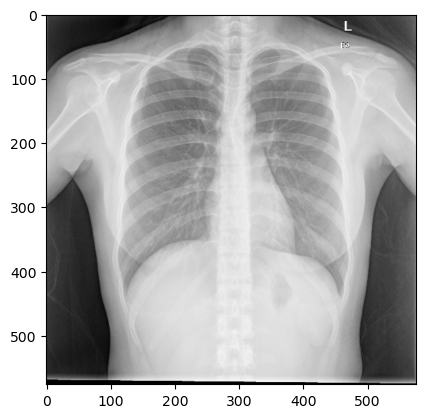

In [33]:
img = cv2.resize(img, (576, 576))
plt.imshow(img)

In [36]:
# import the vgg_unet model
from tf2_sem_seg.models.unet import vgg_unet

In [37]:
# instantiate our model:
# + n_classes = 1 (background) + 1 (lungs)
# + input_height: resized number of rows for input image; must be divisable by 32
# + input_width:  resized number of cols for input image; must be divisable by 32
model = vgg_unet(n_classes=2, input_height=576, input_width=576)

2023-03-16 03:58:05.715917: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:981] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2023-03-16 03:58:05.735668: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:981] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2023-03-16 03:58:05.735926: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:981] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2023-03-16 03:58:05.838764: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2 AVX AVX2 FMA
To enable them in other operation

58889256/58889256 [==============================] - 8s 0us/step


Let us now review the model we just instantiated and compare it against the u-net and vgg16 architectures.


| <img src="https://github.com/georgiosouzounis/lung-seg-xray-unet/raw/main/images/unet.png" width="500"/> | <img src="https://github.com/georgiosouzounis/lung-seg-xray-unet/raw/main/images/vgg16.png" width="500"/> |
|:---:|:---:|
|the u-net architecture | the vgg16 architecture |

In [38]:
# review the model
print(model.summary())

Model: "model_3"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 576, 576, 3  0           []                               
                                )]                                                                
                                                                                                  
 block1_conv1 (Conv2D)          (None, 576, 576, 64  1792        ['input_1[0][0]']                
                                )                                                                 
                                                                                                  
 block1_conv2 (Conv2D)          (None, 576, 576, 64  36928       ['block1_conv1[0][0]']           
                                )                                                           

In [41]:
# review the model
from keras.utils.vis_utils import plot_model
plot_model(model, to_file='model_plot.png', show_shapes=True, show_layer_names=True)

You must install pydot (`pip install pydot`) and install graphviz (see instructions at https://graphviz.gitlab.io/download/) for plot_model to work.


## Train the model <a name="train-the-model"></a>

In [42]:
# create a temporary directory for model checkpoints
%mkdir ../tmp/

mkdir: cannot create directory ‘/content/tmp/’: No such file or directory


In [43]:
# train_images: directory containing the source images for training
# train_annotations: directory containing the masks for training
# checkpoints_path: directory for storing weights and logs
# epochs: the number of training epochs set to 5 for the demo. 
#   Increase this to a higher number for better results.
model.train(
    train_images        =   "../data/images/",
    train_annotations   =   "../data/masks/",
    checkpoints_path    =   "../tmp/vgg_unet_1" ,
    epochs              =   5 
)

Verifying training dataset


100%|██████████| 704/704 [01:50<00:00,  6.40it/s]


Dataset verified! 
Epoch 1/5


2023-03-16 04:04:20.380735: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:428] Loaded cuDNN version 8401
2023-03-16 04:04:25.765873: I tensorflow/compiler/xla/service/service.cc:173] XLA service 0x7fefd898dde0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2023-03-16 04:04:25.765901: I tensorflow/compiler/xla/service/service.cc:181]   StreamExecutor device (0): NVIDIA GeForce RTX 3060, Compute Capability 8.6
2023-03-16 04:04:25.798046: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2023-03-16 04:04:26.066567: I tensorflow/compiler/jit/xla_compilation_cache.cc:477] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


512/512 [==============================] - ETA: 0s - loss: 0.1291 - accuracy: 0.9517
Epoch 1: saving model to ../tmp/vgg_unet_1.00001
512/512 [==============================] - 223s 402ms/step - loss: 0.1291 - accuracy: 0.9517
Epoch 2/5
512/512 [==============================] - ETA: 0s - loss: 0.0625 - accuracy: 0.9777
Epoch 2: saving model to ../tmp/vgg_unet_1.00002
512/512 [==============================] - 200s 390ms/step - loss: 0.0625 - accuracy: 0.9777
Epoch 3/5
512/512 [==============================] - ETA: 0s - loss: 0.0593 - accuracy: 0.9785
Epoch 3: saving model to ../tmp/vgg_unet_1.00003
512/512 [==============================] - 202s 395ms/step - loss: 0.0593 - accuracy: 0.9785
Epoch 4/5
512/512 [==============================] - ETA: 0s - loss: 0.0533 - accuracy: 0.9804
Epoch 4: saving model to ../tmp/vgg_unet_1.00004
512/512 [==============================] - 197s 385ms/step - loss: 0.0533 - accuracy: 0.9804
Epoch 5/5
512/512 [==============================] - ETA: 0s -

In [ ]:
# make a backup in your Google Drive
# %cp ../tmp/* /content/drive/MyDrive/deep-learning/lung-seg-xray/

## Inference on test images <a name="inference-on-test-images"></a>

In [44]:
out = model.predict_segmentation(
    inp         =    "../data/test/CHNCXR_0025_0.png",
    out_fname   =   "../tmp/out.png"
)

1/1 [==============================] - 2s 2s/step


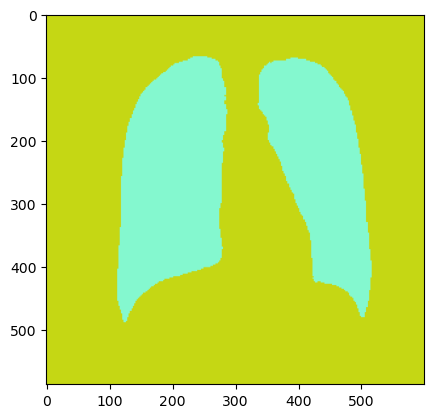

In [48]:
img = cv2.imread("../tmp/out.png")
img = cv2.resize(img, (int(img.shape[1]/5), int(img.shape[0]/5)))
plt.imshow(img,cmap='gray')

In [49]:
# alpha-blend the inference with the source
o = model.predict_segmentation(
        inp             =   "../data/test/CHNCXR_0025_0.png",
        out_fname       =   "../tmp/out_blend.png" ,
        overlay_img     =   True,
        show_legends    =   True,
        class_names     =   ["background","lungs"]
)

1/1 [==============================] - 0s 18ms/step


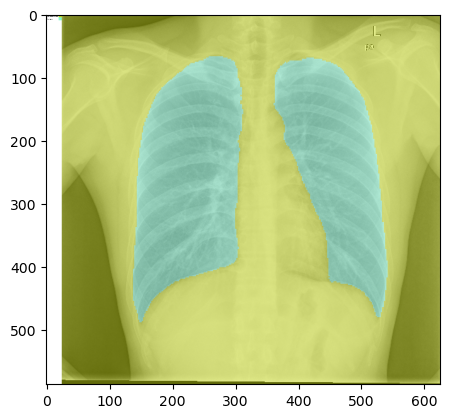

In [50]:
img = cv2.imread("../tmp/out_blend.png")
img = cv2.resize(img, (int(img.shape[1]/5), int(img.shape[0]/5)))
plt.imshow(img, cmap='gray')

## Clean the dataset


In [51]:
%cd ..
!rm -rf data
!rm -rf semantic-segmentation-tf2
!rm -rf tmp

/home/ptn/Base/Learning/Masters/LJMU/Course06_MLOps/Module10_CV2/Unet


In [52]:
# sop this notebook
!jupyter-notebook stop

^C
Traceback (most recent call last):
  File "/home/ptn/Environment/Anaconda3/envs/masters/bin/jupyter-notebook", line 10, in <module>
    sys.exit(main())
  File "/home/ptn/Environment/Anaconda3/envs/masters/lib/python3.9/site-packages/jupyter_core/application.py", line 277, in launch_instance
    return super().launch_instance(argv=argv, **kwargs)
  File "/home/ptn/Environment/Anaconda3/envs/masters/lib/python3.9/site-packages/traitlets/config/application.py", line 992, in launch_instance
    app.start()
  File "/home/ptn/Environment/Anaconda3/envs/masters/lib/python3.9/site-packages/notebook/notebookapp.py", line 2322, in start
    super().start()
  File "/home/ptn/Environment/Anaconda3/envs/masters/lib/python3.9/site-packages/jupyter_core/application.py", line 266, in start
    self.subapp.start()
  File "/home/ptn/Environment/Anaconda3/envs/masters/lib/python3.9/site-packages/notebook/notebookapp.py", line 574, in start
    self._shutdown_or_exit(port, server)
  File "/home/ptn/En

## Acknowledgements <a name="acknowledgements"></a>

The author would like to thank and acknowledge the following:

- [Divan Gupta](https://github.com/divamgupta) and all other contributors to the ```Image Segmentation Keras : Implementation of Segnet, FCN, UNet, PSPNet and other models in Keras``` [repo](https://github.com/divamgupta/image-segmentation-keras) for their amazing work in putting all the functionality together to make semantic segmentation accessible through Keras.
- [Nikhil Pandey](https://www.kaggle.com/nikhilpandey360) for posting an excellent quality X-Ray dataset of thoracic scans in Kaggle.  